# Kidney Stone Risk Dataset - Data Preprocessing

Encode categorical features, standardise, split 80/20, compute DP bounds, and save to pickle.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import pickle
import warnings
warnings.filterwarnings("ignore")


## Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv("./data/cleaned_stone.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (4000, 24)

Columns: ['serum_creatinine', 'gfr', 'bun', 'serum_calcium', 'ana', 'c3_c4', 'hematuria', 'oxalate_levels', 'urine_ph', 'blood_pressure', 'physical_activity', 'diet', 'water_intake', 'smoking', 'alcohol', 'painkiller_usage', 'family_history', 'weight_changes', 'stress_level', 'months', 'cluster', 'ckd_pred', 'ckd_stage', 'stone_risk']

First few rows:


,serum_creatinine,gfr,bun,serum_calcium,ana,c3_c4,hematuria,oxalate_levels,urine_ph,blood_pressure,...,alcohol,painkiller_usage,family_history,weight_changes,stress_level,months,cluster,ckd_pred,ckd_stage,stone_risk
0,0.683683,32.946784,7.553739,10.039896,0,138.204989,0,2.878164,7.864308,115.224217,...,daily,no,yes,stable,low,10,5,CKD,3,1
1,3.809044,32.685035,141.347494,8.330543,1,24.282343,1,4.767639,4.920015,130.143900,...,daily,no,yes,loss,moderate,1,2,CKD,3,1
2,1.143827,2.079805,15.979104,9.419229,0,163.970666,0,1.818613,6.188115,98.026072,...,daily,no,no,stable,moderate,4,6,CKD,5,0
3,4.804657,109.871407,53.307333,7.556631,1,71.056846,1,4.051686,5.278607,142.166650,...,never,yes,yes,stable,high,9,2,CKD,1,1
4,4.920235,42.214590,134.182157,7.289379,1,23.384639,1,3.240920,4.862923,151.962572,...,occasionally,yes,no,gain,high,7,2,CKD,3,1


## Exploratory Analysis

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print(f"\n\nDataset info:")
df.info()


Missing values:
serum_creatinine     0
gfr                  0
bun                  0
serum_calcium        0
ana                  0
c3_c4                0
hematuria            0
oxalate_levels       0
urine_ph             0
blood_pressure       0
physical_activity    0
diet                 0
water_intake         0
smoking              0
alcohol              0
painkiller_usage     0
family_history       0
weight_changes       0
stress_level         0
months               0
cluster              0
ckd_pred             0
ckd_stage            0
stone_risk           0
dtype: int64


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   serum_creatinine   4000 non-null   float64
 1   gfr                4000 non-null   float64
 2   bun                4000 non-null   float64
 3   serum_calcium      4000 non-null   float64
 4   ana           

Target distribution (stone_risk):
stone_risk
0    2433
1    1567
Name: count, dtype: int64

Percentage:
stone_risk
0    60.825
1    39.175
Name: proportion, dtype: float64


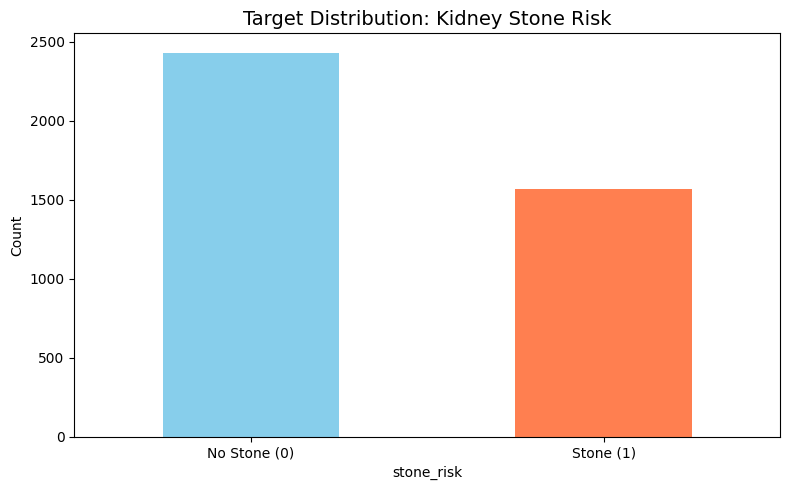

In [4]:
# Target distribution
print("Target distribution (stone_risk):")
print(df["stone_risk"].value_counts())
print(f"\nPercentage:")
print(df["stone_risk"].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
df["stone_risk"].value_counts().plot(kind="bar", color=["skyblue", "coral"])
plt.title("Target Distribution: Kidney Stone Risk", fontsize=14)
plt.xlabel("stone_risk"); plt.ylabel("Count")
plt.xticks([0, 1], ["No Stone (0)", "Stone (1)"], rotation=0)
plt.tight_layout(); plt.show()


In [5]:
# Statistical summary of numeric columns
print("Statistical summary (numeric):")
df.describe()


Statistical summary (numeric):


,serum_creatinine,gfr,bun,serum_calcium,ana,c3_c4,hematuria,oxalate_levels,urine_ph,blood_pressure,water_intake,months,cluster,ckd_stage,stone_risk
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.00000,4000.000000
mean,1.535418,51.684651,39.346088,8.537530,0.300000,109.757723,0.300000,2.624439,6.394127,119.334263,2.505405,6.584250,2.78550,2.91425,0.391750
std,1.204619,33.286679,42.495106,1.403631,0.458315,46.556155,0.458315,1.088755,1.064260,24.684228,0.581993,3.416478,1.80992,1.39100,0.488202
min,0.500273,0.021317,7.000920,5.002407,0.000000,10.027574,0.000000,1.000852,4.500576,90.019471,1.500627,1.000000,0.00000,0.00000,0.000000
25%,0.764889,21.207684,11.632573,7.810761,0.000000,76.770105,0.000000,1.735248,5.258262,100.738443,2.004723,4.000000,2.00000,2.00000,0.000000
50%,0.993766,50.247075,16.296667,8.982200,0.000000,115.511599,0.000000,2.432659,6.579063,111.113002,2.512182,7.000000,2.00000,3.00000,0.000000
75%,1.967041,78.170330,67.090486,9.583627,1.000000,148.532716,1.000000,3.417216,7.289073,136.312001,3.015095,10.000000,4.00000,4.00000,1.000000
max,4.994009,119.923482,149.999395,10.199344,1.000000,179.963970,1.000000,4.999965,7.999886,179.991991,3.499595,12.000000,6.00000,5.00000,1.000000


In [6]:
# Categorical columns overview
cat_cols = ["physical_activity","diet","smoking","alcohol","painkiller_usage",
            "family_history","weight_changes","stress_level","ckd_pred"]
for col in cat_cols:
    print(f"{col}: {df[col].value_counts().to_dict()}")


physical_activity: {'weekly': 1401, 'rarely': 1315, 'daily': 1284}
diet: {'balanced': 1352, 'low salt': 1349, 'high protein': 1299}
smoking: {'no': 2814, 'yes': 1186}
alcohol: {'occasionally': 1347, 'never': 1337, 'daily': 1316}
painkiller_usage: {'no': 3219, 'yes': 781}
family_history: {'yes': 2051, 'no': 1949}
weight_changes: {'stable': 1369, 'loss': 1323, 'gain': 1308}
stress_level: {'moderate': 1375, 'high': 1357, 'low': 1268}
ckd_pred: {'CKD': 3875, 'No CKD': 125}


## Encode Categorical Features

In [7]:
# Label-encode all object/categorical columns except the target
df_encoded = df.copy()
label_encoders = {}

categorical_cols = df_encoded.select_dtypes(include=["object"]).columns.tolist()
if "stone_risk" in categorical_cols:
    categorical_cols.remove("stone_risk")

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nEncoded dataframe shape: {df_encoded.shape}")


Encoded physical_activity: {'daily': np.int64(0), 'rarely': np.int64(1), 'weekly': np.int64(2)}
Encoded diet: {'balanced': np.int64(0), 'high protein': np.int64(1), 'low salt': np.int64(2)}
Encoded smoking: {'no': np.int64(0), 'yes': np.int64(1)}
Encoded alcohol: {'daily': np.int64(0), 'never': np.int64(1), 'occasionally': np.int64(2)}
Encoded painkiller_usage: {'no': np.int64(0), 'yes': np.int64(1)}
Encoded family_history: {'no': np.int64(0), 'yes': np.int64(1)}
Encoded weight_changes: {'gain': np.int64(0), 'loss': np.int64(1), 'stable': np.int64(2)}
Encoded stress_level: {'high': np.int64(0), 'low': np.int64(1), 'moderate': np.int64(2)}
Encoded ckd_pred: {'CKD': np.int64(0), 'No CKD': np.int64(1)}

Encoded dataframe shape: (4000, 24)


## Feature / Target Split

In [8]:
# Separate features and target
X = df_encoded.drop("stone_risk", axis=1)
y = df_encoded["stone_risk"].astype(int)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())


Features shape: (4000, 23)
Target shape: (4000,)

Feature columns (23):
['serum_creatinine', 'gfr', 'bun', 'serum_calcium', 'ana', 'c3_c4', 'hematuria', 'oxalate_levels', 'urine_ph', 'blood_pressure', 'physical_activity', 'diet', 'water_intake', 'smoking', 'alcohol', 'painkiller_usage', 'family_history', 'weight_changes', 'stress_level', 'months', 'cluster', 'ckd_pred', 'ckd_stage']


## Train-Test Split (80/20, stratified)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())


Training set size: 3200 samples
Test set size: 800 samples

Training set target distribution:
stone_risk
0    1946
1    1254
Name: count, dtype: int64

Test set target distribution:
stone_risk
0    487
1    313
Name: count, dtype: int64


## Feature Scaling (MinMaxScaler)

In [10]:
# Initialize MinMaxScaler(feature_range=(-1, 1))
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")
print(f"\nScaled training data statistics:")
print(f"Min: {X_train_scaled.min(axis=0)[:5]}...")
print(f"Max: {X_train_scaled.max(axis=0)[:5]}...")


Scaled training data shape: (3200, 23)
Scaled test data shape: (800, 23)

Scaled training data statistics:
Min: [-1. -1. -1. -1. -1.]...
Max: [1. 1. 1. 1. 1.]...


## Compute DP Bounds

In [11]:
# Theoretical bounds from MinMaxScaler: every feature is in [-1, 1]
n_features = X_train_scaled.shape[1]
lower_bound = np.full(n_features, -1.0)
upper_bound = np.full(n_features, 1.0)
bounds = (lower_bound, upper_bound)
print(f"Theoretical feature bounds (data-independent):")
print(f"  Lower: [-1.0] × {n_features} features")
print(f"  Upper: [+1.0] × {n_features} features")


Theoretical feature bounds (data-independent):
  Lower: [-1.0] × 23 features
  Upper: [+1.0] × 23 features


## Save Preprocessed Data

In [12]:
import os
os.makedirs("data", exist_ok=True)

processed_data = {
    "X_train": X_train_scaled,
    "X_test":  X_test_scaled,
    "y_train": y_train.values,
    "y_test":  y_test.values,
    "feature_names": X.columns.tolist(),
    "bounds": bounds,
    "scaler": scaler,
    "label_encoders": label_encoders
}

with open("data/processed_data.pkl", "wb") as f:
    pickle.dump(processed_data, f)

print("\u2713 Preprocessed data saved to 'data/processed_data.pkl'")
print(f"\nSaved objects:")
print(f"  - X_train: {X_train_scaled.shape}")
print(f"  - X_test:  {X_test_scaled.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test:  {y_test.shape}")
print(f"  - feature_names: {len(X.columns)} features")
print(f"  - bounds: lower and upper bounds for DP")
print(f"  - scaler: MinMaxScaler object")
print(f"  - label_encoders: {len(label_encoders)} categorical encoders")


✓ Preprocessed data saved to 'data/processed_data.pkl'

Saved objects:
  - X_train: (3200, 23)
  - X_test:  (800, 23)
  - y_train: (3200,)
  - y_test:  (800,)
  - feature_names: 23 features
  - bounds: lower and upper bounds for DP
  - scaler: MinMaxScaler object
  - label_encoders: 9 categorical encoders


In [13]:
print("="*60)
print("DATA PREPROCESSING SUMMARY")
print("="*60)
print(f"Dataset: Kidney Stone Risk Prediction Dataset")
print(f"Total samples: {df.shape[0]:,}")
print(f"Features: {X.shape[1]}")
print(f"\nTrain-Test Split (80/20, stratified):")
print(f"  Training: {X_train.shape[0]:,} samples")
print(f"  Test:     {X_test.shape[0]:,} samples")
print(f"\nPreprocessing:")
print(f"  \u2713 Categorical features label-encoded")
print(f"  \u2713 MinMaxScaler applied (range=[-1, 1])")
print(f"  \u2713 Feature bounds computed for DP")
print(f"  \u2713 Data saved to pickle file")
print(f"\nReady for model training!")
print("="*60)


DATA PREPROCESSING SUMMARY
Dataset: Kidney Stone Risk Prediction Dataset
Total samples: 4,000
Features: 23

Train-Test Split (80/20, stratified):
  Training: 3,200 samples
  Test:     800 samples

Preprocessing:
  ✓ Categorical features label-encoded
  ✓ MinMaxScaler applied (range=[-1, 1])
  ✓ Feature bounds computed for DP
  ✓ Data saved to pickle file

Ready for model training!
